# Step 1: Define the Problem
In Linear Regression, we aim to predict a **continuous target variable ($y$)** based on one or more **features ($X$)**.

**Example:** Predicting the median house value ($y$) in California districts based on features like average rooms, population, and median income ($X$).

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # Target: Median House Value (continuous)

print(f"Features: {list(X.columns)}")
print(f"Target type: {y.dtype}")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target type: float64


# Step 2: Exploratory Data Analysis (EDA)
We need to check for missing values, understand distributions, and look for linear relationships using scatter plots.

Missing values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


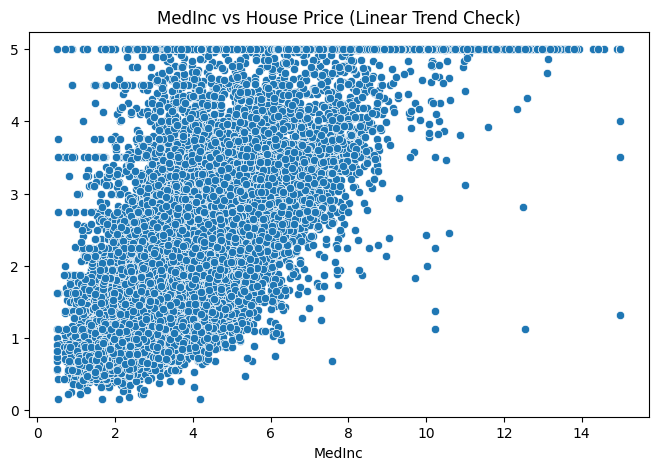

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for nulls
print("Missing values:\n", X.isnull().sum())

# Visualize relationship between Median Income and Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X['MedInc'], y=y)
plt.title('MedInc vs House Price (Linear Trend Check)')
plt.show()

# Step 3: Preprocessing
We handle scaling to ensure features with different units (like 'Population' vs 'MedInc') are treated fairly, and split the data.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into 80/20 train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Train the Model
We use Ordinary Least Squares (OLS) to find the line that minimizes the sum of squared residuals.

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

# Step 5: Evaluation
We measure performance using R² (variance explained), MAE (average error magnitude), and RMSE (penalizes large errors).

R^2 Score: 0.576
MAE: 0.533
RMSE: 0.746


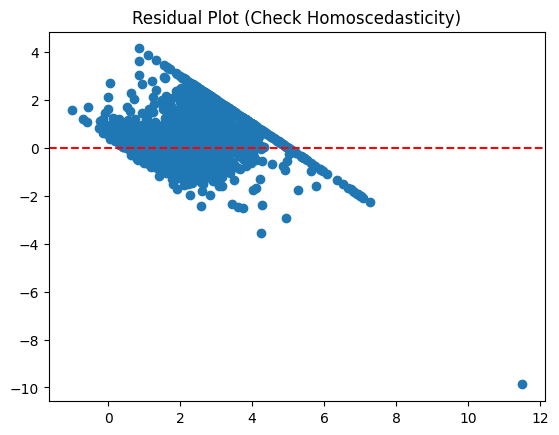

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = model.predict(X_test_scaled)

print(f"R^2 Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.3f}")

# Residual Plot
residuals = y_test - predictions
plt.scatter(predictions, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Check Homoscedasticity)')
plt.show()

# Step 6: Interpret and Iterate
Check the coefficients to see which features impact the price most. If results are poor, consider Ridge (L1) or Lasso (L2) to handle overfitting.

In [6]:
# Coefficients Interpretation
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coeff_df.sort_values(by='Coefficient', ascending=False))

# Note: If high multicollinearity exists, coefficients may be unstable.
# Use sklearn.linear_model.Ridge if coefficients are too large.

,Feature,Coefficient
0,MedInc,0.854383
3,AveBedrms,0.339259
1,HouseAge,0.122546
4,Population,-0.002308
5,AveOccup,-0.040829
2,AveRooms,-0.294410
7,Longitude,-0.869842
6,Latitude,-0.896929
